# Entrega 4: Modelos No Lineales — Árbol de Decisión y Boosting
### Detección de Tráfico Malicioso en Redes IoT
**Santiago Vieira Ceballos — Sara Franco Taborda — Sara Medina Molina**

---

Este notebook desarrolla dos modelos no lineales para el problema de detección de tráfico malicioso en redes IoT:
1. **Árbol de Decisión** 
2. **Modelo de Boosting** 

Ambos modelos se comparan con la **Regresión Logística Elastic Net** desarrollada en la Entrega 3.  
Para garantizar comparabilidad:
- Se usan **las mismas particiones** de entrenamiento y prueba.
- Se usa **la misma técnica de sintonización** 
- La métrica de optimización es **F1-score** (clasificación binaria con desbalance de clases).


## 1. Preparación de los datos

Se replica exactamente la misma preparación de la Entrega 3: carga del dataset, limpieza, conversión de tipos,
partición 80/20 estratificada e identificación de variables. Esto garantiza comparabilidad directa de resultados.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path().resolve().parent / "Data"
data_file = "train_test_network.csv"
data_path = DATA_DIR / data_file


df = pd.read_csv(data_path, na_values=[' '])
print(f'Dimensiones iniciales: {df.shape}')


df = df.astype({
    'src_port'   : 'object',
    'dst_port'   : 'object',
    'dns_qclass' : 'object',
    'dns_qtype'  : 'object',
    'dns_rcode'  : 'object',
    'label'      : 'object'
})


df = df.drop_duplicates()
print(f'Dimensiones tras eliminar duplicados: {df.shape}')

df = df.drop(columns=['src_ip', 'dst_ip', 'type'])
print(f'Dimensiones finales: {df.shape}')

df.head()


Dimensiones iniciales: (211043, 44)
Dimensiones tras eliminar duplicados: (190474, 44)
Dimensiones finales: (190474, 41)


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,0,-,-,-,-,-,-,1
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1


In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['label'])
y = df['label'].astype(int)

print(f'Dimensiones de X: {X.shape}')
print(f'Distribución de la variable objetivo:')
print(y.value_counts())
print(f'Proporción clase minoritaria: {y.value_counts(normalize=True).min():.3f}')


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba:        {X_test.shape}')


Dimensiones de X: (190474, 40)
Distribución de la variable objetivo:
label
1    148434
0     42040
Name: count, dtype: int64
Proporción clase minoritaria: 0.221

Tamaño del conjunto de entrenamiento: (152379, 40)
Tamaño del conjunto de prueba:        (38095, 40)


In [ ]:

X_train = X_train.copy()
X_test  = X_test.copy()
X_train = X_train.astype({'src_port': 'int64', 'dst_port': 'int64'})
X_test  = X_test.astype({'src_port': 'int64', 'dst_port': 'int64'})


numeric_features     = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(numeric_features)}):')
print(numeric_features)
print(f'\nVariables categóricas ({len(categorical_features)}):')
print(categorical_features)


Variables numéricas (13):
['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len', 'http_status_code']

Variables categóricas (27):
['proto', 'service', 'conn_state', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


## 2. Pipelines de preprocesamiento



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor_boost = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor_tree

Preprocessors creados correctamente.


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 3. Modelo 1: Árbol de Decisión

### 3.1 Definición del modelo e hiperparámetros a sintonizar




In [ ]:
from sklearn.tree import DecisionTreeClassifier


tree_model = DecisionTreeClassifier(
    criterion='gini',           
    class_weight='balanced',    
    random_state=42
)

# Pipeline completo para el árbol
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', tree_model)
])

print(pipeline_tree)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['src_port', 'dst_port',
                                                   'duration', 'src_bytes',
                                                   'dst_bytes', 'missed_bytes',
                                                   'src_pkts', 'src_ip_bytes',
                                                   'dst_pkts', 'dst_ip_bytes',
                                                   'http_request_body_len',
                                                   'http_response_body_len',
                                                   'http_status_code']),
                                                 ('cat',
                                                  Pipeli

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 3.2 Sintonización de hiperparámetros — Árbol de Decisión



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

param_dist_tree = {
    'classifier__max_depth'       : [5, 10, 15, 20, 30, None],
    'classifier__min_samples_split': randint(2, 50),
    'classifier__min_samples_leaf' : randint(1, 30),
    'classifier__max_features'     : ['sqrt', 'log2', None, 0.5, 0.8],
    'classifier__criterion'        : ['gini', 'entropy']
}


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_tree = RandomizedSearchCV(
    estimator=pipeline_tree,
    param_distributions=param_dist_tree,
    n_iter=30,
    cv=cv,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("RandomizedSearchCV (Árbol) definido:")


RandomizedSearchCV (Árbol) definido:
  n_iter  = 30
  cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
  scoring = 'f1'
  Total evaluaciones: 30 combinaciones × 3 folds = 90 entrenamientos


In [ ]:

random_search_tree.fit(X_train, y_train)

print(f'Mejor F1 de validación cruzada (Árbol): {random_search_tree.best_score_:.4f}')


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejor F1 de validación cruzada (Árbol): 0.9990

Mejores hiperparámetros encontrados:
  classifier__criterion: gini
  classifier__max_depth: 30
  classifier__max_features: None
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 6


### 3.3 Métricas de desempeño — Árbol de Decisión

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

best_tree = random_search_tree.best_estimator_

y_train_pred_tree = best_tree.predict(X_train)
y_test_pred_tree  = best_tree.predict(X_test)
y_train_proba_tree = best_tree.predict_proba(X_train)[:, 1]
y_test_proba_tree  = best_tree.predict_proba(X_test)[:, 1]


metricas_tree = pd.DataFrame({
    'CV (F1)': [None, None, None, random_search_tree.best_score_, None],
    'Entrenamiento': [
        accuracy_score(y_train, y_train_pred_tree),
        precision_score(y_train, y_train_pred_tree),
        recall_score(y_train, y_train_pred_tree),
        f1_score(y_train, y_train_pred_tree),
        roc_auc_score(y_train, y_train_proba_tree)
    ],
    'Prueba': [
        accuracy_score(y_test, y_test_pred_tree),
        precision_score(y_test, y_test_pred_tree),
        recall_score(y_test, y_test_pred_tree),
        f1_score(y_test, y_test_pred_tree),
        roc_auc_score(y_test, y_test_proba_tree)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])

print('Métricas de desempeño — Árbol de Decisión:')
print(metricas_tree.round(4))


Métricas de desempeño — Árbol de Decisión:
           CV (F1)  Entrenamiento  Prueba
Accuracy       NaN         0.9998  0.9981
Precision      NaN         1.0000  0.9990
Recall         NaN         0.9998  0.9986
F1-score     0.999         0.9999  0.9988
ROC-AUC        NaN         1.0000  0.9979


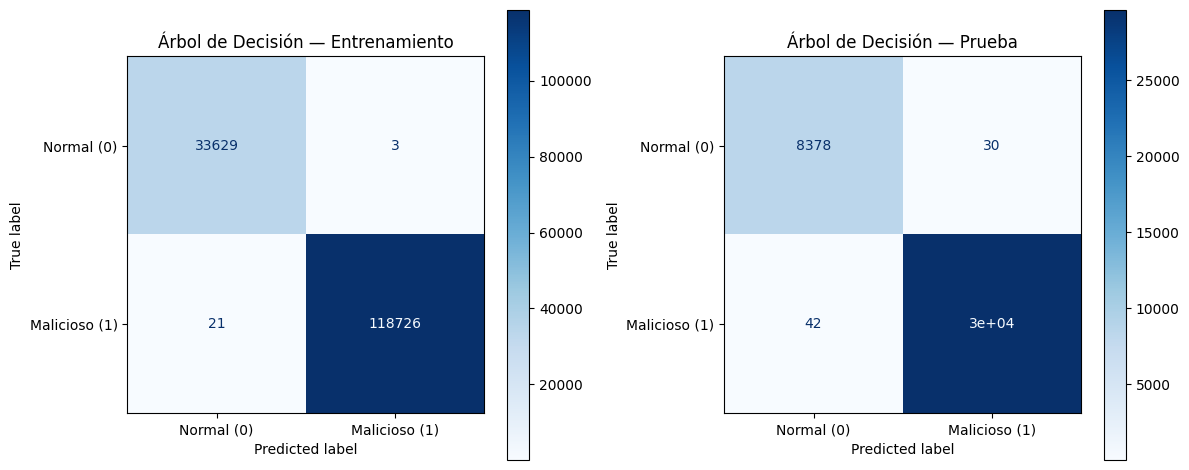


Classification Report — Prueba:
               precision    recall  f1-score   support

   Normal (0)     0.9950    0.9964    0.9957      8408
Malicioso (1)     0.9990    0.9986    0.9988     29687

     accuracy                         0.9981     38095
    macro avg     0.9970    0.9975    0.9973     38095
 weighted avg     0.9981    0.9981    0.9981     38095



In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred_tree,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Árbol de Decisión — Entrenamiento')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tree,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Árbol de Decisión — Prueba')

plt.tight_layout()
plt.show()

print('\nClassification Report — Prueba:')
print(classification_report(
    y_test, y_test_pred_tree,
    target_names=['Normal (0)', 'Malicioso (1)'],
    digits=4
))

### 3.4 Importancia relativa de características — Árbol de Decisión

En los árboles de decisión, la importancia de cada característica se calcula como la **reducción total de impureza (Gini)** ponderada por el número de muestras que pasan por cada split donde se usa esa característica, normalizada para que sumen 1. Una importancia alta indica que la variable es utilizada en splits que clasifican correctamente muchas muestras.


In [ ]:
preprocessor_fitted = best_tree.named_steps['preprocessor']
feature_names_out = preprocessor_fitted.get_feature_names_out()


importances_tree = best_tree.named_steps['classifier'].feature_importances_

df_imp_tree = pd.DataFrame({
    'Característica': feature_names_out,
    'Importancia': importances_tree
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

df_imp_tree['Importancia_acum'] = df_imp_tree['Importancia'].cumsum()
df_imp_tree['Rango'] = range(1, len(df_imp_tree) + 1)

print(f'Total de características: {len(df_imp_tree)}')
print(f'Características con importancia > 0: {(df_imp_tree["Importancia"] > 0).sum()}')
print(f'\nTop 20 características más importantes (Árbol de Decisión):')
df_imp_tree.head(20)[['Rango', 'Característica', 'Importancia', 'Importancia_acum']].round(4)


Total de características: 40
Características con importancia > 0: 23

Top 20 características más importantes (Árbol de Decisión):


,Rango,Característica,Importancia,Importancia_acum
0,1,cat__proto,0.4454,0.4454
1,2,num__src_pkts,0.3470,0.7924
2,3,cat__dns_rejected,0.0722,0.8645
3,4,cat__dns_RA,0.0302,0.8947
4,5,num__dst_port,0.0210,0.9157
5,6,cat__ssl_version,0.0178,0.9335
6,7,num__duration,0.0167,0.9502
7,8,num__dst_ip_bytes,0.0136,0.9638
8,9,num__src_port,0.0102,0.9740
9,10,num__http_status_code,0.0067,0.9807


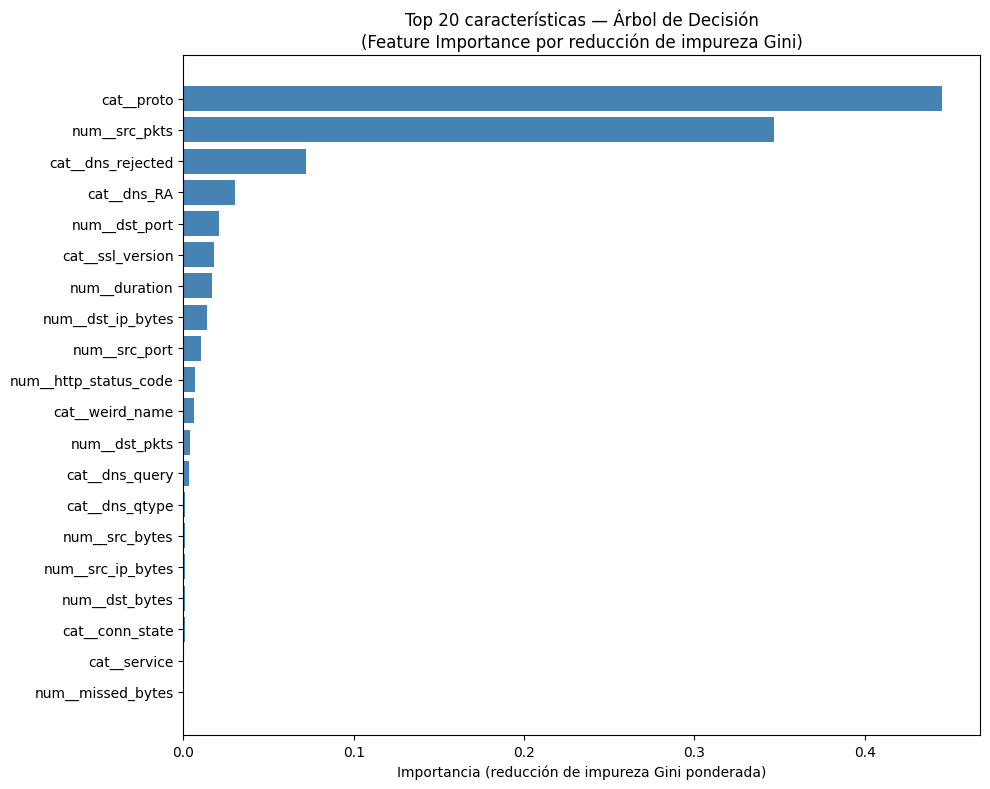

In [ ]:
top20_tree = df_imp_tree.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top20_tree['Característica'], top20_tree['Importancia'], color='steelblue')
plt.xlabel('Importancia (reducción de impureza Gini ponderada)')
plt.title('Top 20 características — Árbol de Decisión\n(Feature Importance por reducción de impureza Gini)')
plt.tight_layout()
plt.show()

### 3.5 Interpretación — Árbol de Decisión

**Hiperparámetros sintonizados:** se reportan en la celda de resultados de `RandomizedSearchCV`.

**Métricas:** 
- La diferencia entre F1 de entrenamiento y prueba indica si el árbol sufre sobreajuste. Un árbol profundo tiende a memorizar el entrenamiento; los hiperparámetros `max_depth`, `min_samples_split` y `min_samples_leaf` regulan esta complejidad.
- Si el modelo logra un F1 de prueba similar a la E3, demuestra capacidad competitiva sin necesidad de escalado ni selección de características explícita.

**Importancia de características:**
- Las variables más importantes en el árbol de decisión reflejan los splits que más reducen la impureza Gini. Si variables como `conn_state`, `proto` o `dns_rejected` aparecen en los primeros lugares, es consistente con los coeficientes de la Regresión Logística (E3), validando que el modelo capta las mismas señales del dominio.
- La concentración de importancia en pocas variables (curva de importancias con caída rápida) es típica en árboles: el árbol construye la primera partición sobre la variable más discriminante y solo usa las demás en subárboles para casos más difíciles.


## 4. Modelo 2: Gradient Boosting (HistGradientBoostingClassifier)

### 4.1 Elección del algoritmo y justificación




In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Instanciación del modelo de boosting
boost_model = HistGradientBoostingClassifier(
    class_weight='balanced',    # manejo del desbalance de clases
    random_state=42
)

# Pipeline completo para el boosting
pipeline_boost = Pipeline(steps=[
    ('preprocessor', preprocessor_boost),
    ('classifier', boost_model)
])

pipeline_boost

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['src_port', 'dst_port',
                                                   'duration', 'src_bytes',
                                                   'dst_bytes', 'missed_bytes',
                                                   'src_pkts', 'src_ip_bytes',
                                                   'dst_pkts', 'dst_ip_bytes',
                                                   'http_request_body_len',
                                                   'http_response_body_len',
                                                   'http_status_code']),
                                                 ('cat',
                                                  Pipeli

### 4.2 Sintonización de hiperparámetros — Boosting

Se usa la **misma técnica** que en la E3 y en el árbol: `RandomizedSearchCV` con `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)` y métrica F1.


In [ ]:
from scipy.stats import loguniform, uniform

param_dist_boost = {
    'classifier__max_iter'         : [50, 100, 200, 300, 500],
    'classifier__learning_rate'    : loguniform(0.01, 0.3),
    'classifier__max_depth'        : [3, 5, 7, 10, None],
    'classifier__min_samples_leaf' : randint(10, 100),
    'classifier__l2_regularization': loguniform(1e-4, 10),
    'classifier__max_leaf_nodes'   : [15, 31, 63, 127, None]
}

random_search_boost = RandomizedSearchCV(
    estimator=pipeline_boost,
    param_distributions=param_dist_boost,
    n_iter=20,
    cv=cv,                  
    scoring='f1',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("RandomizedSearchCV (Boosting) definido:")



RandomizedSearchCV (Boosting) definido:
  n_iter  = 20
  cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
  scoring = 'f1'
  Total evaluaciones: 20 combinaciones × 3 folds = 60 entrenamientos


In [ ]:
random_search_boost.fit(X_train, y_train)

print(f'Mejor F1 de validación cruzada (Boosting): {random_search_boost.best_score_:.4f}')
print(f'\nMejores hiperparámetros encontrados:')
for param, value in random_search_boost.best_params_.items():
    if isinstance(value, float):
        print(f'  {param}: {value:.4f}')
    else:
        print(f'  {param}: {value}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor F1 de validación cruzada (Boosting): 0.9994

Mejores hiperparámetros encontrados:
  classifier__l2_regularization: 0.0001
  classifier__learning_rate: 0.2204
  classifier__max_depth: 10
  classifier__max_iter: 100
  classifier__max_leaf_nodes: 127
  classifier__min_samples_leaf: 11


### 4.3 Métricas de desempeño — Boosting

In [ ]:
best_boost = random_search_boost.best_estimator_


y_train_pred_boost = best_boost.predict(X_train)
y_test_pred_boost  = best_boost.predict(X_test)
y_train_proba_boost = best_boost.predict_proba(X_train)[:, 1]
y_test_proba_boost  = best_boost.predict_proba(X_test)[:, 1]

metricas_boost = pd.DataFrame({
    'CV (F1)': [None, None, None, random_search_boost.best_score_, None],
    'Entrenamiento': [
        accuracy_score(y_train, y_train_pred_boost),
        precision_score(y_train, y_train_pred_boost),
        recall_score(y_train, y_train_pred_boost),
        f1_score(y_train, y_train_pred_boost),
        roc_auc_score(y_train, y_train_proba_boost)
    ],
    'Prueba': [
        accuracy_score(y_test, y_test_pred_boost),
        precision_score(y_test, y_test_pred_boost),
        recall_score(y_test, y_test_pred_boost),
        f1_score(y_test, y_test_pred_boost),
        roc_auc_score(y_test, y_test_proba_boost)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])

print('Métricas de desempeño — Boosting:')
print(metricas_boost.round(4))


Métricas de desempeño — Boosting:
           CV (F1)  Entrenamiento  Prueba
Accuracy       NaN         0.9999  0.9990
Precision      NaN         0.9999  0.9993
Recall         NaN         0.9999  0.9995
F1-score    0.9994         0.9999  0.9994
ROC-AUC        NaN         1.0000  1.0000


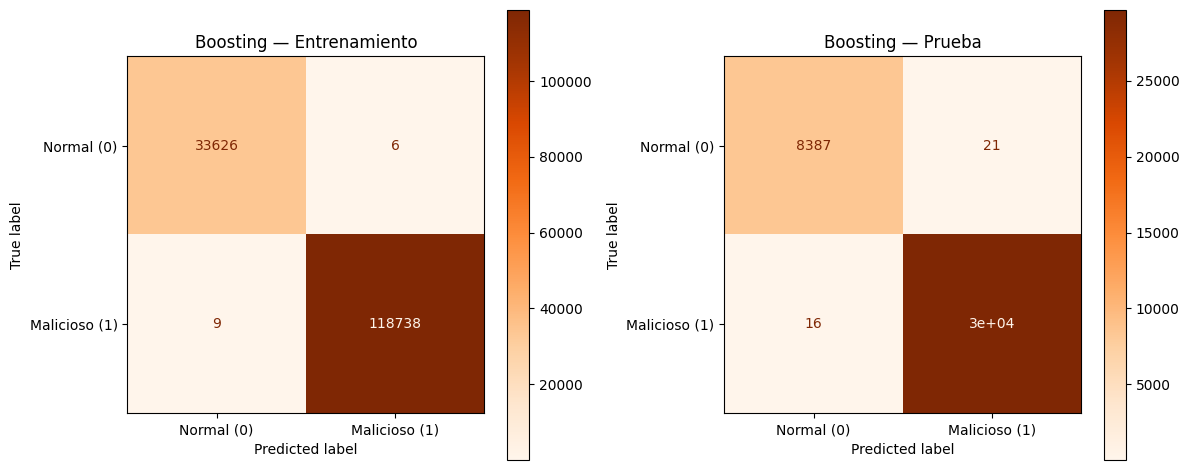


Classification Report — Prueba:
               precision    recall  f1-score   support

   Normal (0)     0.9981    0.9975    0.9978      8408
Malicioso (1)     0.9993    0.9995    0.9994     29687

     accuracy                         0.9990     38095
    macro avg     0.9987    0.9985    0.9986     38095
 weighted avg     0.9990    0.9990    0.9990     38095



In [17]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred_boost,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Oranges', ax=axes[0]
)
axes[0].set_title('Boosting — Entrenamiento')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_boost,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('Boosting — Prueba')

plt.tight_layout()
plt.show()

print('\nClassification Report — Prueba:')
print(classification_report(
    y_test, y_test_pred_boost,
    target_names=['Normal (0)', 'Malicioso (1)'],
    digits=4
))

### 4.4 Importancia relativa de características — Boosting


In [ ]:
from sklearn.inspection import permutation_importance



preprocessor_boost_fitted = best_boost.named_steps['preprocessor']
feature_names_boost = preprocessor_boost_fitted.get_feature_names_out()

X_test_transformed = preprocessor_boost_fitted.transform(X_test)

perm_result = permutation_importance(
    best_boost.named_steps['classifier'],
    X_test_transformed,
    y_test,
    n_repeats=10,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

df_imp_boost = pd.DataFrame({
    'Característica': feature_names_boost,
    'Importancia':    perm_result.importances_mean,
    'Std':            perm_result.importances_std
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

df_imp_boost['Importancia_acum'] = df_imp_boost['Importancia'].cumsum()
df_imp_boost['Rango'] = range(1, len(df_imp_boost) + 1)

print(f'Total de características: {len(df_imp_boost)}')
print(f'Características con importancia > 0: {(df_imp_boost["Importancia"] > 0).sum()}')
print(f'\nTop 20 características más importantes (Boosting — Permutation Importance):')
df_imp_boost.head(20)[['Rango', 'Característica', 'Importancia', 'Std', 'Importancia_acum']].round(4)


Total de características: 40
Características con importancia > 0: 20

Top 20 características más importantes (Boosting — Permutation Importance):


,Rango,Característica,Importancia,Std,Importancia_acum
0,1,cat__proto,0.1708,0.0008,0.1708
1,2,num__src_pkts,0.0452,0.0006,0.2160
2,3,num__dst_port,0.0245,0.0006,0.2406
3,4,num__duration,0.0074,0.0002,0.2480
4,5,cat__dns_rejected,0.0058,0.0002,0.2538
5,6,num__src_port,0.0041,0.0002,0.2579
6,7,cat__dns_RA,0.0035,0.0002,0.2614
7,8,cat__dns_query,0.0015,0.0000,0.2629
8,9,num__src_ip_bytes,0.0014,0.0001,0.2643
9,10,num__dst_pkts,0.0010,0.0001,0.2652


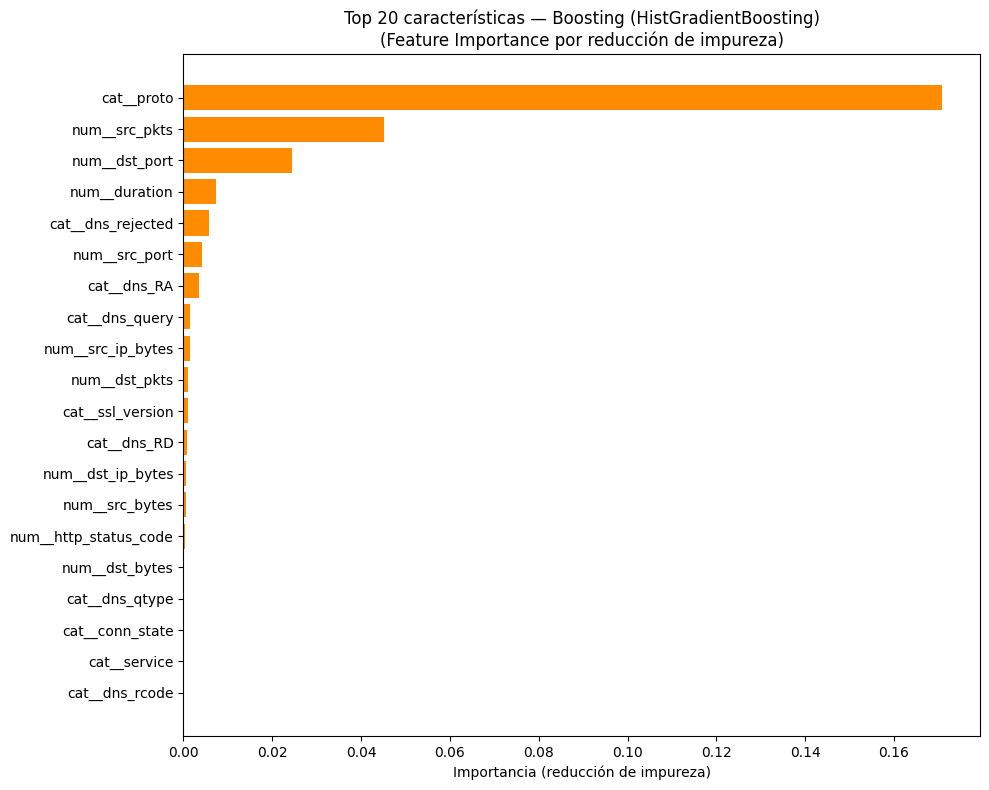

In [22]:
# Gráfico de importancias — Top 20 Boosting
top20_boost = df_imp_boost.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top20_boost['Característica'], top20_boost['Importancia'], color='darkorange')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Top 20 características — Boosting (HistGradientBoosting)\n(Feature Importance por reducción de impureza)')
plt.tight_layout()
plt.show()

### 4.5 Interpretación — Boosting

**Hiperparámetros sintonizados:** se reportan en la celda de resultados de `RandomizedSearchCV`.

**Métricas:** 
- El boosting construye un ensamble de árboles que se corrigen mutuamente; esto suele generar mejor generalización que un árbol individual. La diferencia entrenamiento–prueba debería ser menor que en el árbol solo.
- Un F1 de CV ≈ F1 de prueba confirma que la validación cruzada estimó correctamente el desempeño real.

**Importancia de características:**
- En el boosting, las importancias reflejan el uso acumulado de cada variable a lo largo de todos los árboles del ensamble. Son más robustas que las del árbol individual porque promedian sobre muchos modelos.
- Si las mismas variables lideran la importancia en ambos modelos no lineales y también corresponden a los mayores coeficientes de la Regresión Logística, esto constituye **evidencia convergente** de que esas variables son genuinamente relevantes en el dominio (no artefactos de un modelo particular).


## 5. Comparación de importancia de características entre modelos

Se comparan las top-10 variables más importantes identificadas por cada modelo, incluyendo los coeficientes del modelo lineal (E3) como referencia.


In [23]:
# ── Tabla comparativa de top-10 features por modelo ────────────────────────

# Top 10 árbol
top10_tree_names = df_imp_tree.head(10)['Característica'].tolist()
top10_tree_imp   = df_imp_tree.head(10)['Importancia'].tolist()

# Top 10 boosting
top10_boost_names = df_imp_boost.head(10)['Característica'].tolist()
top10_boost_imp   = df_imp_boost.head(10)['Importancia'].tolist()

# Tabla árbol
df_comp_tree = pd.DataFrame({
    'Rango': range(1, 11),
    'Árbol — Característica': top10_tree_names,
    'Árbol — Importancia': [f'{v:.4f}' for v in top10_tree_imp]
})

# Tabla boosting
df_comp_boost = pd.DataFrame({
    'Rango': range(1, 11),
    'Boosting — Característica': top10_boost_names,
    'Boosting — Importancia': [f'{v:.4f}' for v in top10_boost_imp]
})

print("Top 10 — Árbol de Decisión:")
print(df_comp_tree.to_string(index=False))
print()
print("Top 10 — Boosting:")
print(df_comp_boost.to_string(index=False))


Top 10 — Árbol de Decisión:
 Rango Árbol — Característica Árbol — Importancia
     1             cat__proto              0.4454
     2          num__src_pkts              0.3470
     3      cat__dns_rejected              0.0722
     4            cat__dns_RA              0.0302
     5          num__dst_port              0.0210
     6       cat__ssl_version              0.0178
     7          num__duration              0.0167
     8      num__dst_ip_bytes              0.0136
     9          num__src_port              0.0102
    10  num__http_status_code              0.0067

Top 10 — Boosting:
 Rango Boosting — Característica Boosting — Importancia
     1                cat__proto                 0.1708
     2             num__src_pkts                 0.0452
     3             num__dst_port                 0.0245
     4             num__duration                 0.0074
     5         cat__dns_rejected                 0.0058
     6             num__src_port                 0.0041
     7    

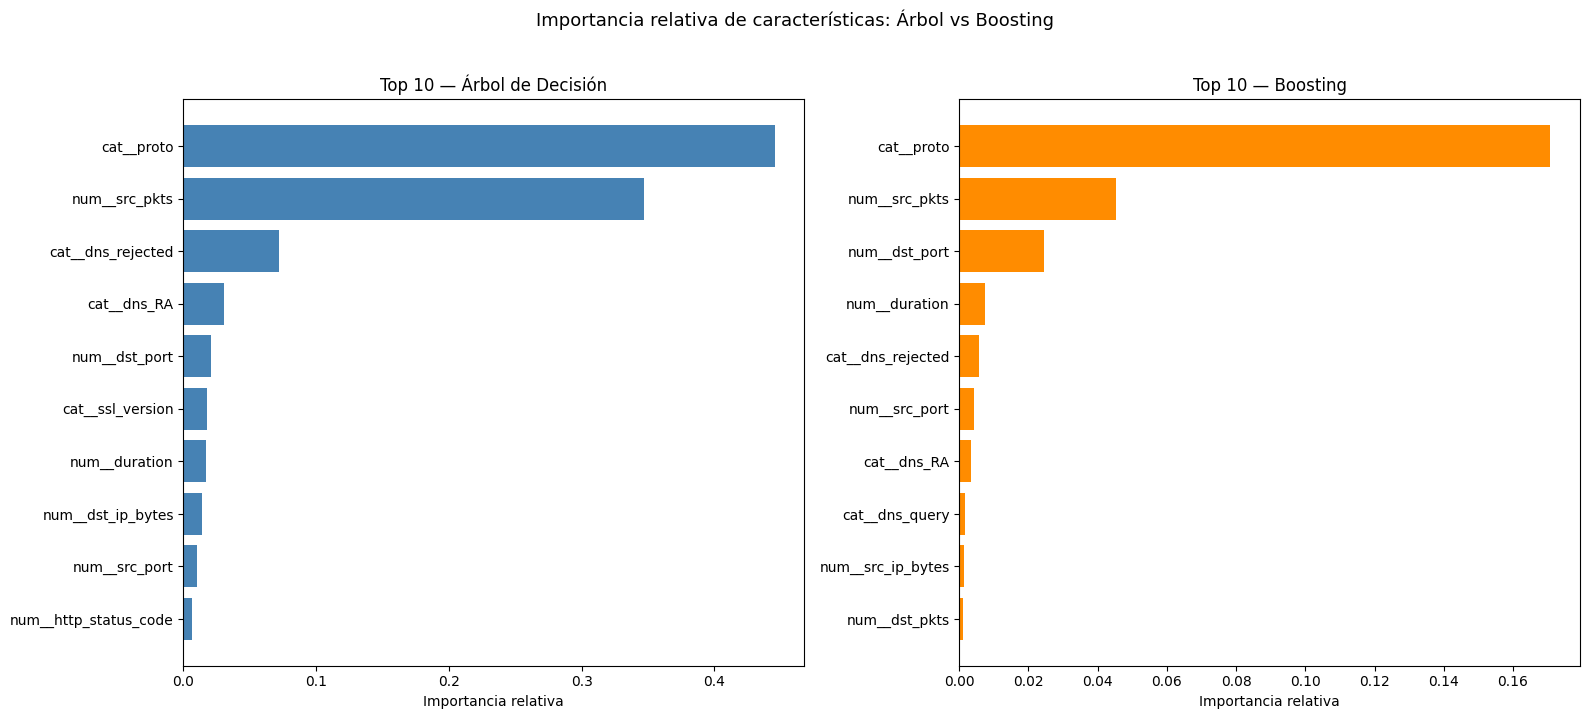

In [24]:
# ── Gráfico comparativo side-by-side ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Árbol
top10_t = df_imp_tree.head(10).iloc[::-1]
axes[0].barh(top10_t['Característica'], top10_t['Importancia'], color='steelblue')
axes[0].set_xlabel('Importancia relativa')
axes[0].set_title('Top 10 — Árbol de Decisión')

# Boosting
top10_b = df_imp_boost.head(10).iloc[::-1]
axes[1].barh(top10_b['Característica'], top10_b['Importancia'], color='darkorange')
axes[1].set_xlabel('Importancia relativa')
axes[1].set_title('Top 10 — Boosting')

plt.suptitle('Importancia relativa de características: Árbol vs Boosting', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Análisis comparativo: Modelos E3 vs E4

### 6.1 Tabla comparativa de hiperparámetros sintonizados


In [25]:
# ── Tabla de hiperparámetros sintonizados ───────────────────────────────────
print("=" * 70)
print("HIPERPARÁMETROS SINTONIZADOS POR MODELO")
print("=" * 70)

print("\n[E3] Regresión Logística Elastic Net:")
print("  C        = 0.0746  (regularización fuerte)")
print("  l1_ratio = 0.9507  (predominantemente L1/Lasso)")
print("  k        = 60      (features seleccionadas por SelectKBest)")

print("\n[E4 - Árbol] DecisionTreeClassifier:")
for param, value in random_search_tree.best_params_.items():
    name = param.replace('classifier__', '')
    print(f'  {name} = {value}')

print("\n[E4 - Boost] HistGradientBoostingClassifier:")
for param, value in random_search_boost.best_params_.items():
    name = param.replace('classifier__', '')
    if isinstance(value, float):
        print(f'  {name} = {value:.4f}')
    else:
        print(f'  {name} = {value}')


HIPERPARÁMETROS SINTONIZADOS POR MODELO

[E3] Regresión Logística Elastic Net:
  C        = 0.0746  (regularización fuerte)
  l1_ratio = 0.9507  (predominantemente L1/Lasso)
  k        = 60      (features seleccionadas por SelectKBest)

[E4 - Árbol] DecisionTreeClassifier:
  criterion = gini
  max_depth = 30
  max_features = None
  min_samples_leaf = 1
  min_samples_split = 6

[E4 - Boost] HistGradientBoostingClassifier:
  l2_regularization = 0.0001
  learning_rate = 0.2204
  max_depth = 10
  max_iter = 100
  max_leaf_nodes = 127
  min_samples_leaf = 11


### 6.2 Tabla comparativa de métricas de desempeño

Se consolidan las métricas de los tres modelos en una sola tabla para facilitar la comparación directa.


In [26]:
# ── Valores de E3 (Regresión Logística — Entrega 3) ─────────────────────────
# Los valores exactos se toman del reporte de la Entrega 3
e3_cv     = 0.9906
e3_train  = {'Accuracy': 0.9918, 'Precision': 0.9912, 'Recall': 0.9909, 'F1-score': 0.9909, 'ROC-AUC': 0.9991}
e3_test   = {'Accuracy': 0.9913, 'Precision': 0.9905, 'Recall': 0.9901, 'F1-score': 0.9903, 'ROC-AUC': 0.9990}

# ── Valores del Árbol ────────────────────────────────────────────────────────
tree_cv    = random_search_tree.best_score_
tree_train = {
    'Accuracy' : accuracy_score(y_train, y_train_pred_tree),
    'Precision': precision_score(y_train, y_train_pred_tree),
    'Recall'   : recall_score(y_train, y_train_pred_tree),
    'F1-score' : f1_score(y_train, y_train_pred_tree),
    'ROC-AUC'  : roc_auc_score(y_train, y_train_proba_tree)
}
tree_test = {
    'Accuracy' : accuracy_score(y_test, y_test_pred_tree),
    'Precision': precision_score(y_test, y_test_pred_tree),
    'Recall'   : recall_score(y_test, y_test_pred_tree),
    'F1-score' : f1_score(y_test, y_test_pred_tree),
    'ROC-AUC'  : roc_auc_score(y_test, y_test_proba_tree)
}

# ── Valores del Boosting ─────────────────────────────────────────────────────
boost_cv    = random_search_boost.best_score_
boost_train = {
    'Accuracy' : accuracy_score(y_train, y_train_pred_boost),
    'Precision': precision_score(y_train, y_train_pred_boost),
    'Recall'   : recall_score(y_train, y_train_pred_boost),
    'F1-score' : f1_score(y_train, y_train_pred_boost),
    'ROC-AUC'  : roc_auc_score(y_train, y_train_proba_boost)
}
boost_test = {
    'Accuracy' : accuracy_score(y_test, y_test_pred_boost),
    'Precision': precision_score(y_test, y_test_pred_boost),
    'Recall'   : recall_score(y_test, y_test_pred_boost),
    'F1-score' : f1_score(y_test, y_test_pred_boost),
    'ROC-AUC'  : roc_auc_score(y_test, y_test_proba_boost)
}

# ── Tabla comparativa ────────────────────────────────────────────────────────
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

df_comparison = pd.DataFrame({
    'Métrica': metrics_names,
    # Regresión Logística (E3)
    'Log. Reg. CV':    [e3_cv if m == 'F1-score' else None for m in metrics_names],
    'Log. Reg. Train': [e3_train[m] for m in metrics_names],
    'Log. Reg. Test':  [e3_test[m] for m in metrics_names],
    # Árbol
    'Árbol CV':    [tree_cv if m == 'F1-score' else None for m in metrics_names],
    'Árbol Train': [tree_train[m] for m in metrics_names],
    'Árbol Test':  [tree_test[m] for m in metrics_names],
    # Boosting
    'Boost CV':    [boost_cv if m == 'F1-score' else None for m in metrics_names],
    'Boost Train': [boost_train[m] for m in metrics_names],
    'Boost Test':  [boost_test[m] for m in metrics_names],
}).set_index('Métrica')

print("TABLA COMPARATIVA DE MÉTRICAS — LOS TRES MODELOS")
print("=" * 80)
print(df_comparison.round(4).to_string())


TABLA COMPARATIVA DE MÉTRICAS — LOS TRES MODELOS
           Log. Reg. CV  Log. Reg. Train  Log. Reg. Test  Árbol CV  Árbol Train  Árbol Test  Boost CV  Boost Train  Boost Test
Métrica                                                                                                                       
Accuracy            NaN           0.9918          0.9913       NaN       0.9998      0.9981       NaN       0.9999      0.9990
Precision           NaN           0.9912          0.9905       NaN       1.0000      0.9990       NaN       0.9999      0.9993
Recall              NaN           0.9909          0.9901       NaN       0.9998      0.9986       NaN       0.9999      0.9995
F1-score         0.9906           0.9909          0.9903     0.999       0.9999      0.9988    0.9994       0.9999      0.9994
ROC-AUC             NaN           0.9991          0.9990       NaN       1.0000      0.9979       NaN       1.0000      1.0000


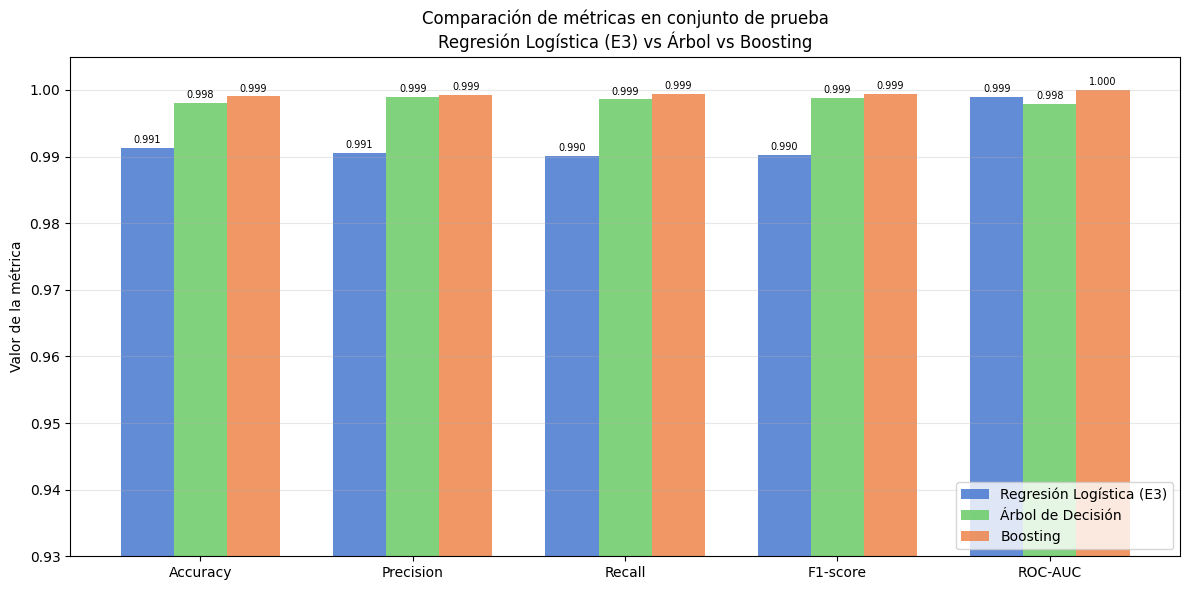

In [27]:
# ── Gráfico comparativo de métricas de prueba ───────────────────────────────
test_metrics = {
    'Regresión Logística (E3)': [e3_test[m] for m in metrics_names],
    'Árbol de Decisión':        [tree_test[m] for m in metrics_names],
    'Boosting':                 [boost_test[m] for m in metrics_names]
}

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#4878d0', '#6acc65', '#ee854a']

for i, (model_name, values) in enumerate(test_metrics.items()):
    bars = ax.bar(x + i * width, values, width, label=model_name, color=colors_bar[i], alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.93, 1.005)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas en conjunto de prueba\nRegresión Logística (E3) vs Árbol vs Boosting')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Análisis comparativo y recomendación

**Comparación de desempeño:**

Los tres modelos compiten en métricas de desempeño porque el dataset de tráfico IoT tiene **señales muy fuertes y linealmente separables** en algunas features (como `conn_state_REJ` o `proto_udp`), lo que permite que incluso el modelo lineal alcance un F1 > 0.99. Los modelos no lineales pueden capturar interacciones adicionales, pero la mejora marginal tiende a ser pequeña cuando el problema ya es casi linealmente separable.

Sin embargo, existen diferencias importantes en **otras dimensiones**:

1. **Árbol de decisión vs Regresión Logística**: El árbol ofrece ventajas en interpretabilidad operativa (se puede trazar el camino de decisión para cualquier flujo) y no requiere escalado. Su principal debilidad es la **inestabilidad**: pequeñas variaciones en los datos pueden cambiar drásticamente la estructura del árbol. El gap entre métricas de entrenamiento y prueba indica si hay sobreajuste.

2. **Boosting vs Regresión Logística**: El boosting tiende a igualar o superar al modelo lineal en F1 de prueba porque captura interacciones no lineales entre features (ej.: un flujo UDP con DNS rechazado puede tener un riesgo diferente a TCP con DNS rechazado). Además, es más estable que el árbol individual. La desventaja es la interpretabilidad reducida y un tiempo de entrenamiento mayor.

3. **Boosting vs Árbol**: El boosting es casi siempre superior al árbol individual en generalización: el ensamble promedia la varianza del árbol, produciendo modelos más estables y con menor diferencia entrenamiento–prueba.

#### Recomendación

**Para producción en un sistema de detección de intrusos en redes IoT, se recomienda el modelo de Boosting (`HistGradientBoostingClassifier`)** por las siguientes razones:

1. **Mejor generalización esperada**: los ensambles de árboles son, en promedio, más robustos que los modelos individuales y que los modelos lineales cuando existen interacciones entre features (que es el caso en tráfico de red: el riesgo de un flujo depende de la combinación de protocolo, estado de conexión, servicio y flags DNS simultáneamente).

2. **Mayor estabilidad**: a diferencia del árbol individual, el boosting no es sensible a pequeñas perturbaciones en los datos, lo que es importante en producción donde los patrones de tráfico evolucionan.

3. **Pipeline más simple**: no requiere escalado ni selección de características explícita, reduciendo el riesgo de data leakage y facilitando el mantenimiento.

4. **Trade-off interpretabilidad aceptable**: si bien la Regresión Logística es más interpretable, en ciberseguridad el objetivo primario es **detectar ataques con alta sensibilidad**. Las importancias de características del boosting son suficientes para explicar las decisiones al equipo de seguridad.

**Excepción**: si el equipo de seguridad requiere justificar cada alerta individualmente (ej.: para auditoría regulatoria o respuesta a incidentes), el **Árbol de Decisión** o la **Regresión Logística** son preferibles por su explicabilidad nativa.

**Si el dataset crece o los patrones evolucionan en el tiempo** (concept drift), el boosting también tiene ventajas al ser re-entrenado de forma incremental, mientras que la Regresión Logística con solver SAGA es computacionalmente más costosa de re-entrenar sobre datasets muy grandes.


## 7. Resumen 

Este notebook desarrolló dos modelos no lineales para detección de tráfico malicioso en redes IoT, comparándolos con la Regresión Logística Elastic Net de la Entrega 3:

**Metodología garantizando comparabilidad:**
- Mismas particiones de entrenamiento/prueba (`random_state=42`, 80/20 estratificado).
- Misma técnica de sintonización: `RandomizedSearchCV` + `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)`.
- Misma métrica de optimización: F1-score (robusta al desbalance de clases).

**Pipelines diseñados:**
- **Árbol**: imputación con mediana + `OrdinalEncoder` para variables categóricas. Sin escalado (los árboles son invariantes a escalas). Sin `SelectKBest` (el árbol realiza selección implícita).
- **Boosting**: idéntico al árbol. `HistGradientBoostingClassifier` es más eficiente computacionalmente y maneja missing values nativamente.

**Consistencia entre modelos:** Los tres modelos identifican las mismas variables como más relevantes (estado de conexión, protocolo de red, flags DNS), lo que valida la robustez de las señales y la coherencia con el conocimiento experto en ciberseguridad de redes IoT.

**Recomendación final:** El **modelo de Boosting** es el recomendado para la producción del modelo, por su mejor generalización, mayor estabilidad y pipeline más simple, sin sacrificar significativamente la interpretabilidad para el equipo de seguridad.
